In [1]:
import pandas as pd 
import numpy as np
import re

In [2]:
df=pd.read_csv("ahmedabad.csv")

# Data Cleaning And Feature Engineering

In [3]:
df = df.drop(columns=['Unnamed: 0','status','facing','description'])

In [4]:
# Converting 'value_area' from sqyrd to sqft

extract = df['value_area'].str.extract(r'(\d+\.?\d*)\s*([a-z,A-Z]+)')
extract.columns = ['value','units']
extract['value'] = pd.to_numeric(extract['value'])
df['value_area'] = extract.apply( lambda x:x['value']*9 if isinstance(x['units'],str) and 'sqyrd' in x['units'].lower() else x['value'],axis=1
)

In [5]:
# Normalize 'value_area' based on type of area measured 

excluded_category = ['Under Construction','Transaction','Status']
df= df.query('type_area not in @excluded_category')
def normalize_area(dataframe):
    a_type = dataframe['type_area']
    value = dataframe['value_area']
    if a_type == 'Carpet Area':
        return value 
    elif a_type == 'Super Area':
        return value/1.35
    elif a_type == 'Built Area':
        return value/1.15
    else:
        return value

df['value_area'] =df.apply(normalize_area,axis=1)
df=df.drop(columns=['type_area'])

In [6]:
# Fix values that are misplaces in 'transaction' and 'furnishing' columns

transaction_category = ['Resale','New Property']
furnishing_category = ['Unfurnished','Furnished','Semi-Furnished']
df['furnishing'] = df.apply(lambda x:x['furnishing'] if x['transaction'] not in furnishing_category else x['transaction'],axis=1 )
df['transaction'] = df.apply(lambda x:x['transaction'] if x['floor'] not in transaction_category else x['floor'],axis =1)
df = df.query("transaction in @transaction_category and furnishing in @furnishing_category ")

In [7]:
# Get the ralative floor value and replace some noice with meadian of 'floor' column's value

df['floor']  = df.apply(lambda x:np.nan if x["floor"] in transaction_category else x['floor'] ,axis=1 )
def get_ralitive_floor(val):
    val = str(val).lower()

    floor_num=None
    if 'ground' in val: floor_num=0
    elif 'lower basement' in val: floor_num=-2
    elif 'upper basement' in val: floor_num=-1

    nums = re.findall(r'\d+',val)

    if len(nums)>=2:
        return int(nums[0])/int(nums[1]) if int(nums[1])!= 0 else 0
    elif len(nums)==1:
        return 0
   
df['floor'] = df['floor'].apply(get_ralitive_floor)
meadian_val = df.loc[df['floor']!=0.00,'floor'].median()
df['floor']=df['floor'].replace(np.nan,meadian_val)

In [8]:
#Extract BHK value from Title field

df["BHK"] = df["Title"].str.extract(r'(\d+)')
df['BHK'] = pd.to_numeric(df["BHK"])
df['BHK'] = df["BHK"].fillna(df['BHK'].median())

In [9]:
# Retrive price and price per sqrft from uncleaned columns and normalize new columns

def get_price_value(val):
    val = str(val).lower().strip()

    if "cal" in val or val == 'nan':
        return np.nan

    if 'sqft' in val:
        num_match = re.search(r'(\d+\,?\d*)',val)
        if not num_match:
            return np.nan
        price = float(num_match.group(1).replace(',',''))
        return price
        
    num_match = re.search(r'(\d+\.?\d*)',val)
    if not num_match:
        return np.nan
    price = float(num_match.group(1))

    if 'cr' in val:
        return price*100
    elif 'lac' in val:
        return price

    return price
df["price_in_lacs"]= df['price'].apply(get_price_value)
df["price_sqft_in_thousend"] = df['price_sqft'].apply(get_price_value)
df = df[df['price_sqft_in_thousend'] <= 21000]
#fill nan vlaue of 'price_sqft_in_thousend' and remove nan value in price column

df=df[df['price_in_lacs'].notna()]
df = df.drop(columns=['price','price_sqft'])


In [10]:
# Convert furnished and transaction to numeric data for models can easily work on data 

df['is_New_Property']  =  df['transaction'].apply(lambda x:1 if x=="New Property" else 0)
df['is_Furnished']  =  df['furnishing'].apply(lambda x:0 if x=="Unfurnished" else(1 if x=="Semi-Furnished" else 2))
df = df.drop(columns=['furnishing','transaction'])

In [11]:
ahmedabad_flat_areas = {
    "premium_luxury": [
        "Satellite",
        "Bodakdev",
        "Prahlad Nagar",
        "Vastrapur",
        "Navrangpura",
        "Ambawadi",
        "Paldi",
        "Ellisbridge",
        "Ashram Road",
        "Drive In Road",
        "Judges Bungalow Road",
        "Sindhu Bhavan Marg",
        "SG Highway",
        "Science City",
        "Ambli",      
        "Thaltej",   
    ],

    "mid_segment": [
        "Bopal",
        "Gota",
        "South Bopal",
        "Ghatlodiya",
        "Sola",
        "Naranpura",
        "Memnagar",
        "Gurukul",
        "Vasna",
        "Jivraj Park",
        "Maninagar",
        "Chandkheda",
        "Motera",
        "Shahibaug",
        "Vaishnodevi Circle",
        "Iscon Ambli Road",
        "Sarkhej",
        "Shela",      
        "Shilaj",    
        "Ghuma",      
    ],

    "affordable_budget": [
        "Nikol",
        "Naroda",
        "Nava Naroda",
        "Vastral",
        "Vatva",
        "Narolgam",
        "Jagatpur",
        "Ghodasar",
        "Isanpur",
        "Narol",
        "Odhav",
        "Bapunagar",
        "Amraiwadi",
        "Saraspur",
        "Juhapura",
        "Nikol Naroda Road",
        "Tragad",
        "Chandlodiya",
        "New Ranip",
        "Ranip",
        "Nava Vadaj",
        "Hathijan",
    ],

    "emerging_upcoming": [
        "Ognaj",      
        "Zundal",
        "Bhadaj",
        "Hebatpur",
        "Chharodi",
        "Sanand",
        "Daskroi",
        "Kathwada",
        "Lambha",
        "Sanathal",
        "Godhavi",
        "Changodar",
        "Sughad",
        "Bhat",
        "Moraiya",
        "Hansol",
        "Godrej Garden City",
        "Nandej",
        "Kuha",
    ],

    "old_city_central": [
        "Kalupur",
        "Shahpur",
        "Khanpur",
        "Dariyapur",
        "Jamalpur",
        "Behrampura",
        "Khadia",
        "Sarangpur",
        "Usmanpura",
        "Meghaninagar",
        "Sabarmati",
        "Naroda Road",
        "Law Garden",
        "CG Road",
    ],
}

all_areas = [
    area
    for areas in ahmedabad_flat_areas.values()
    for area in areas
]
all_areas_sorted = sorted(all_areas,key=len,reverse=True)

In [12]:
# Get the area name by running all values of title columns against predefine list of area 'price_in_lacs'

def get_city_area(val):
    val = str(val).lower().strip()

    if ',' in val:
        areaName= val.split(',')[-1].strip()
    elif 'sale in' in val:
        match = re.search(r'sale in\s*(.*)', val)
        areaName = match.group(1) if match else val
    else:
        areaName = val

    for area in all_areas_sorted:
        if area.lower() in areaName:
          return area.title()
            
    if 'Ahmedabad' in areaName:
        areaName = re.sub(r'Ahmedabad', '', areaName, flags=re.IGNORECASE)
        return areaName.title()
    return areaName.title() 
    
df["Area Name"]=df['Title'].apply(get_city_area)

# Removing area that have less than 10 flat in area cause those are many and can effect very much to over model
area_counts= df['Area Name'].value_counts()
mask = df['Area Name'].map(lambda x:area_counts[x]>=10)
df['Area Name'] = df['Area Name'].where(mask,np.nan)
df=df.drop(columns=['Title'])
df.rename(columns={'value_area':'Area_in_sqft','floor':'Relative_Floor_Level'},inplace=True)


In [13]:
# Created new column for mean price each area to help in models

df['Area_in_sqft'] = df['Area_in_sqft'].round()
df['Area Name'] = df["Area Name"].apply(lambda x:"Sarkhej" if x == "Sarkhej Ahmedabad" else x)
df['Area Name'] = df["Area Name"].apply(lambda x:"Other" if x == "Ahmedabad Ahmedabad" or x == "Ahmedabad"  else x)
df['Area Name'] = df['Area Name'].astype(str)
df['Area Name'] = df['Area Name'].apply(lambda x: x.replace('Ahmedabad','') if 'Ahmedabad' in x else x) 

In [14]:
df = df[df['Area Name'] != 'nan']

In [15]:
# Convertig area to area_encoding by taking moving mean of each area with KFold to prevent data leackage.

from sklearn.model_selection import KFold
def get_optimized_encoding(df,m=10):
    df=df.copy()
    df['Area Name'] = df['Area Name'].str.strip().str.lower()
    
    target='price_sqft_in_thousend'
    category='Area Name'
    global_mean=df[target].mean()
    df["Area_Encoded"] = np.nan

    kf = KFold(n_splits=5,shuffle=True,random_state=42)

    for train_idx,val_idx in kf.split(df):
        train_fold = df.iloc[train_idx]

        stats = train_fold.groupby(category)[target].agg(['count','mean'])
        smoothed_mean = (stats['count'] * stats['mean']+m*global_mean)/(stats['count']+m)

        df.loc[df.index[val_idx],'Area_Encoded'] = df.loc[df.index[val_idx],category].map(smoothed_mean)

    df['Area_Encoded'] = df['Area_Encoded'].fillna(global_mean)

    return df,global_mean

df_ready,train_global_avg = get_optimized_encoding(df,m=10)


In [16]:
#pd.set_option('display.max_rows', 10)
#df_ready[df_ready["Area Name"]=="sindhu bhavan marg"]


In [17]:
# # saving dictonary of areaNames and thier mean of price per sqft in json file for future use

# import json 

# def save_mapping(mapping_series,global_mean,filename='area_mapping_.json'):
#     data = {
#         'mapping':mapping_series.to_dict(),
#         'global_mean':float(global_mean)
#     }

#     with open(filename,'w') as f:
#         json.dump(data,f,indent=4)
#     print(f"Successfully saved to {filename}")

# area_lookup = df_ready.groupby('Area Name')['Area_Encoded'].mean()

# save_mapping(area_lookup, train_global_avg)

# EDA & Data Visualization

## EDA of numeric columns

In [18]:
df_ready["Area_in_sqft"].describe()

count      5785.000000
mean       1999.655315
std        9933.461048
min           7.000000
25%         889.000000
50%        1485.000000
75%        2556.000000
max      750000.000000
Name: Area_in_sqft, dtype: float64

In [19]:
# Removing area that are more than 10000 sqft those are noice.

df_ready['temp'] = df_ready["price_in_lacs"] *100000 / df_ready['Area_in_sqft']
df_ready['temp'].describe()
df_ready=df_ready[~((df_ready["temp"]>=25000)|  (df_ready['temp']<=3000))]
df_ready=df_ready[df_ready['Area_in_sqft']<=10000]
df_ready=df_ready.drop(columns=['temp'])
df_ready["Area_in_sqft"].describe()

count    5625.000000
mean     1887.107378
std      1208.319033
min        41.000000
25%       904.000000
50%      1510.000000
75%      2589.000000
max      8000.000000
Name: Area_in_sqft, dtype: float64

<Axes: ylabel='Frequency'>

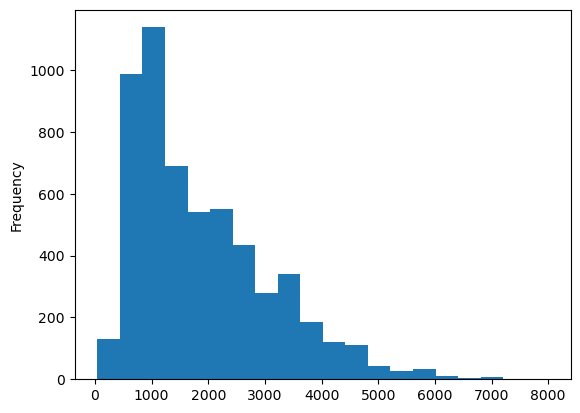

In [20]:
df_ready["Area_in_sqft"].plot(kind="hist",bins=20)

<Axes: >

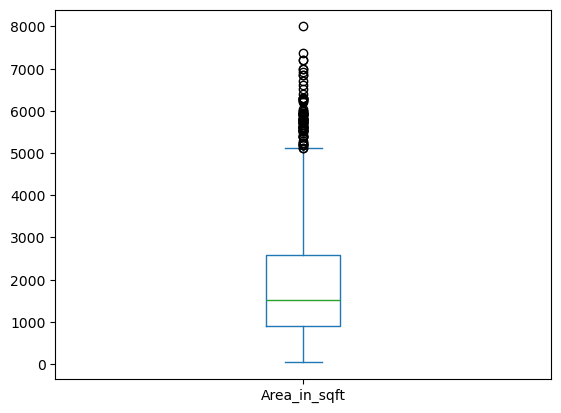

In [21]:
df_ready["Area_in_sqft"].plot(kind="box")

<Axes: ylabel='Density'>

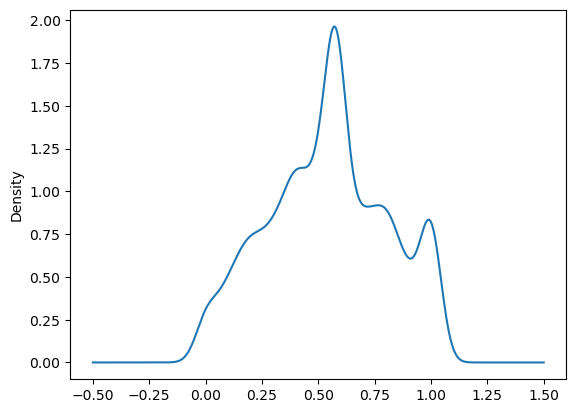

In [23]:
df_ready['Relative_Floor_Level'].plot(kind="kde")

In [24]:
df_ready["price_in_lacs"].describe()

count    5625.000000
mean      216.212871
std       193.965804
min         8.000000
25%        60.500000
50%       138.000000
75%       315.000000
max      1672.000000
Name: price_in_lacs, dtype: float64

np.float64(1.4025024631093994)

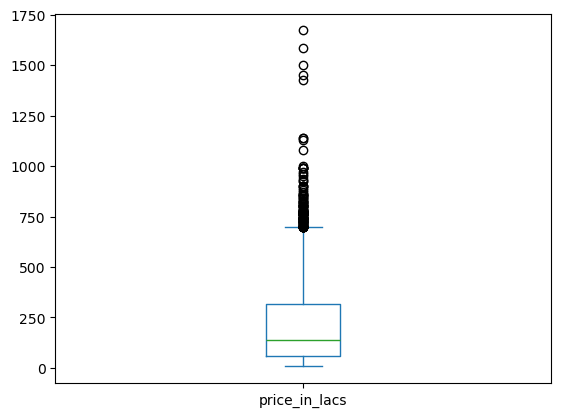

In [25]:
df_ready["price_in_lacs"].plot(kind="box")
df_ready["price_in_lacs"].skew()

In [26]:
df_ready['price_sqft_in_thousend'].describe()

count     5625.00000
mean      6564.86240
std       2364.47413
min       1984.00000
25%       4686.00000
50%       6250.00000
75%       8258.00000
max      20833.00000
Name: price_sqft_in_thousend, dtype: float64

np.float64(0.7142576102016971)

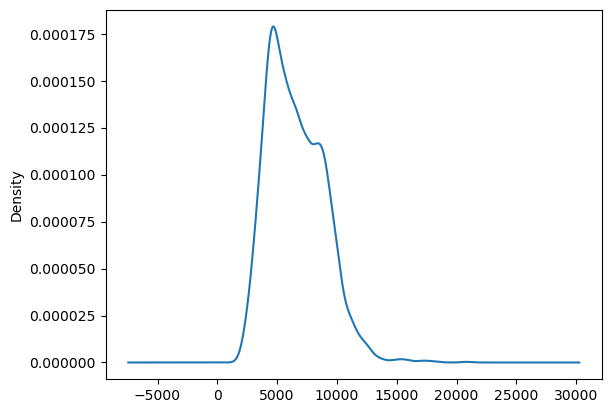

In [27]:
df_ready['price_sqft_in_thousend'].plot(kind='kde')
df_ready['price_sqft_in_thousend'].skew()

In [28]:
df_ready['Area_Encoded'].describe()

count    5625.000000
mean     6635.171436
std      1547.538142
min      3106.127333
25%      5563.633668
50%      6060.590625
75%      7878.442086
max      9536.543897
Name: Area_Encoded, dtype: float64

<Axes: ylabel='Frequency'>

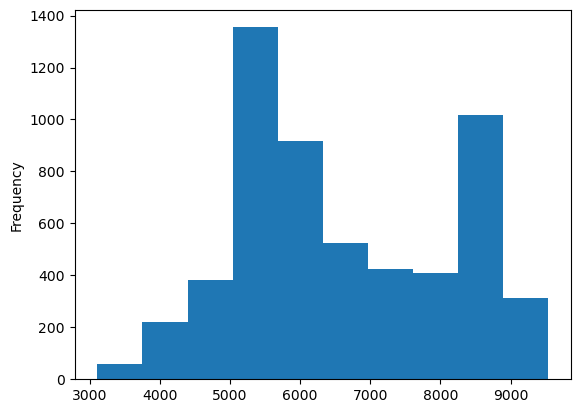

In [29]:
df_ready['Area_Encoded'].plot(kind='hist',bins=10)

np.float64(0.25022802506706676)

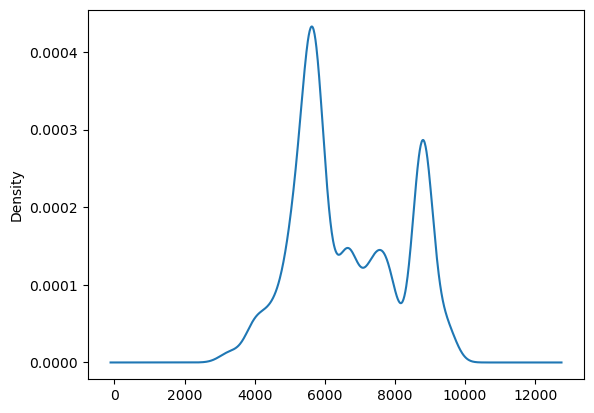

In [30]:
df_ready['Area_Encoded'].plot(kind='kde')
df_ready['Area_Encoded'].skew()

## EDA of categoty columns 

In [31]:
df_ready["BHK"].value_counts()

BHK
4.0    1979
3.0    1558
2.0    1302
5.0     519
1.0     239
6.0      25
8.0       1
9.0       1
7.0       1
Name: count, dtype: int64

<Axes: xlabel='BHK'>

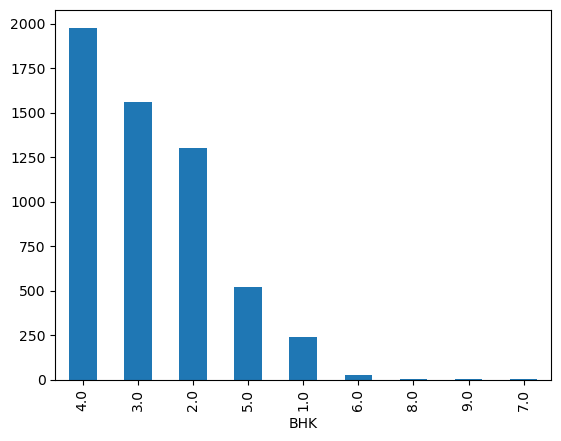

In [32]:
df_ready["BHK"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

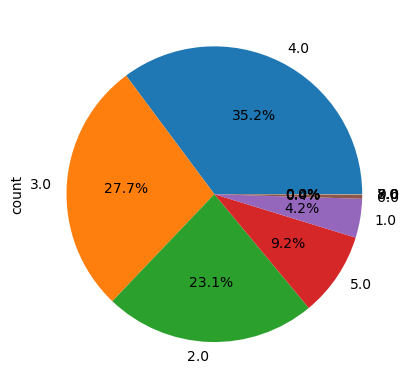

In [33]:
df_ready["BHK"].value_counts().plot(kind="pie",autopct='%0.1f%%')

In [34]:
df_ready["is_New_Property"].value_counts()

is_New_Property
0    3403
1    2222
Name: count, dtype: int64

<Axes: ylabel='count'>

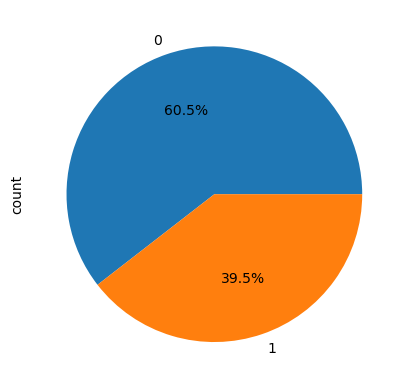

In [35]:
df_ready["is_New_Property"].value_counts().plot(kind="pie",autopct='%0.1f%%')

In [36]:
pd.set_option('display.max_rows', 10)
df_ready['is_Furnished'].value_counts()

is_Furnished
0    3740
2    1068
1     817
Name: count, dtype: int64

<Axes: ylabel='count'>

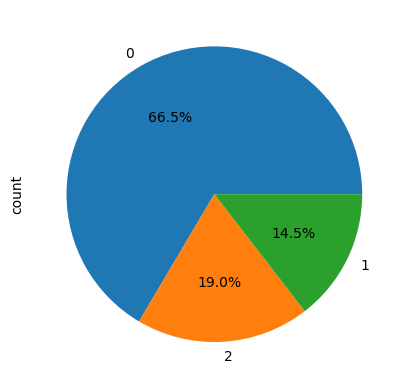

In [37]:
df_ready["is_Furnished"].value_counts().plot(kind="pie",autopct='%0.1f%%')

In [ ]:
#df_ready["Area_Encoded"].value_counts().plot(kind="bar")

## EDA - Bivariate Analysis

### Numeric with Numeric

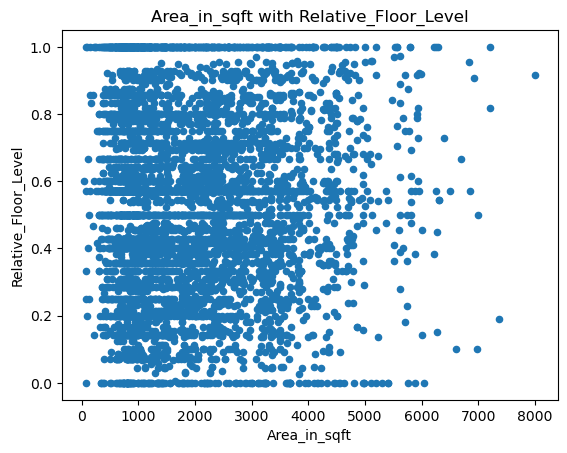

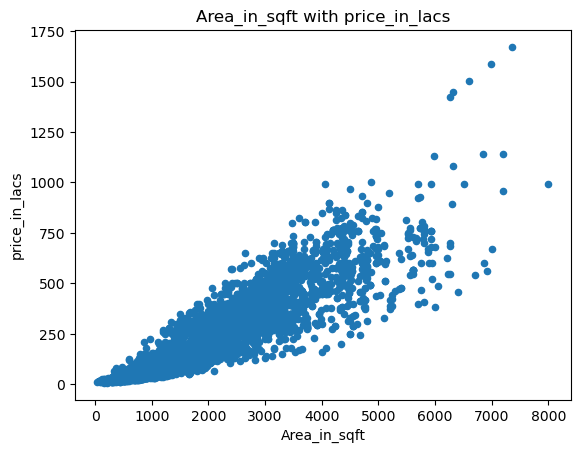

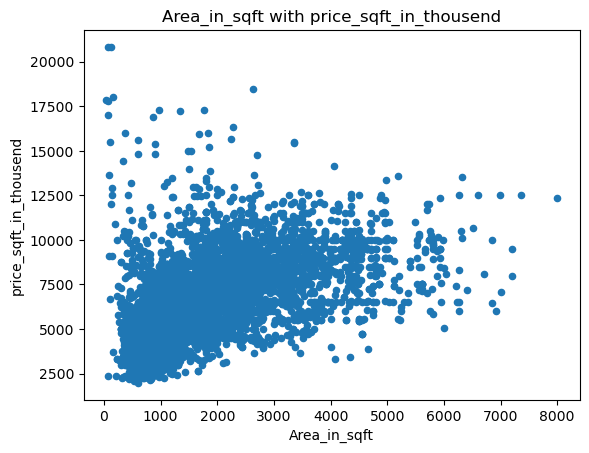

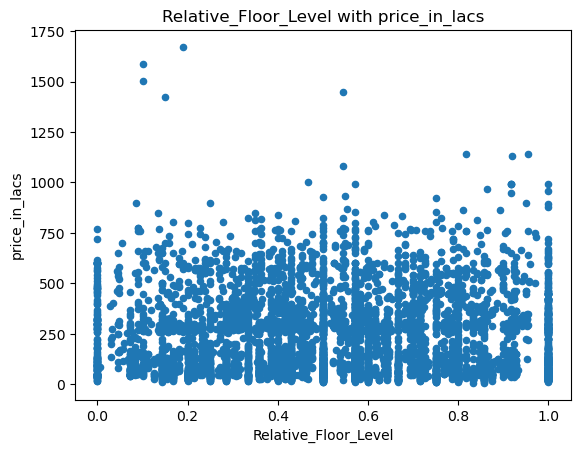

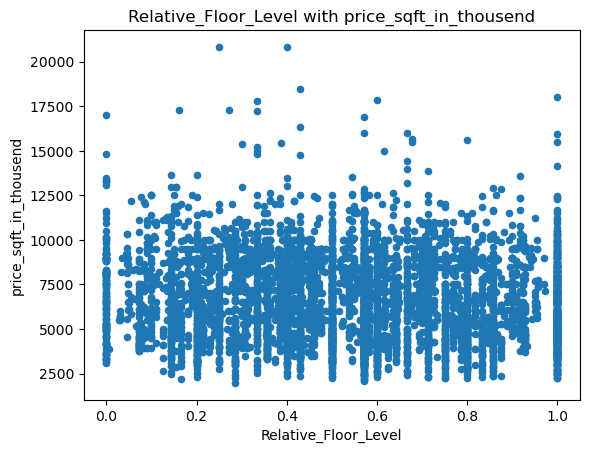

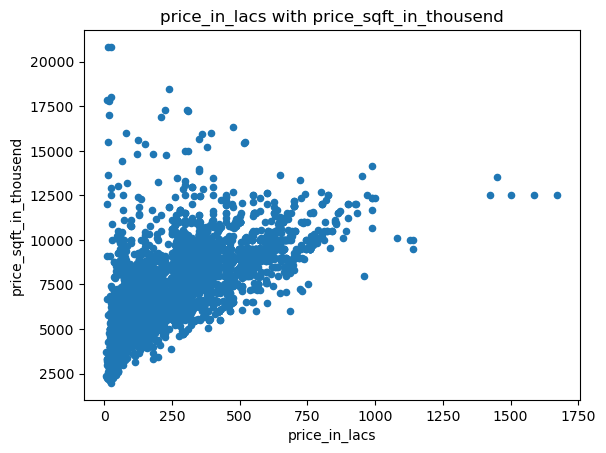

In [38]:
num_cols=["Area_in_sqft","Relative_Floor_Level","price_in_lacs","price_sqft_in_thousend"]
cat_cols=["BHK","is_New_Property","is_Furnished"]
for i in range(len(num_cols)):
    for j in range(i+1,len(num_cols)):
        col=num_cols[i]
        col2=num_cols[j]
        df_ready.plot.scatter(x=col,y=col2,title=col + " with " + col2)


### Numeric - Categorical

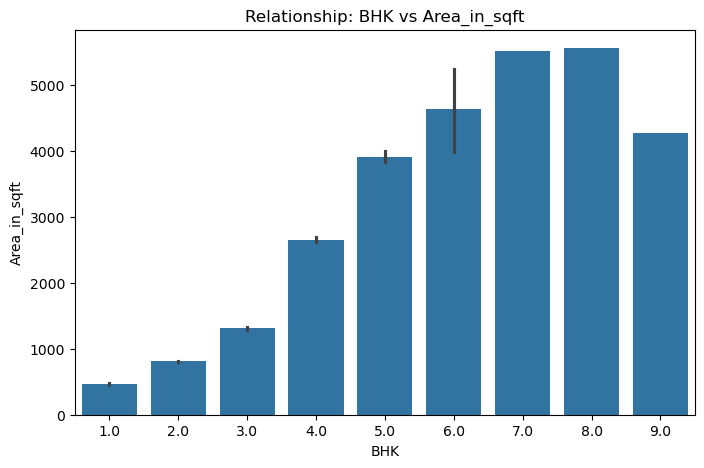

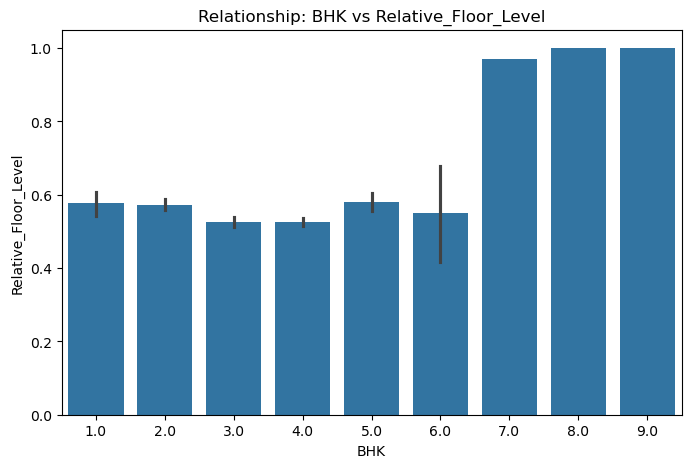

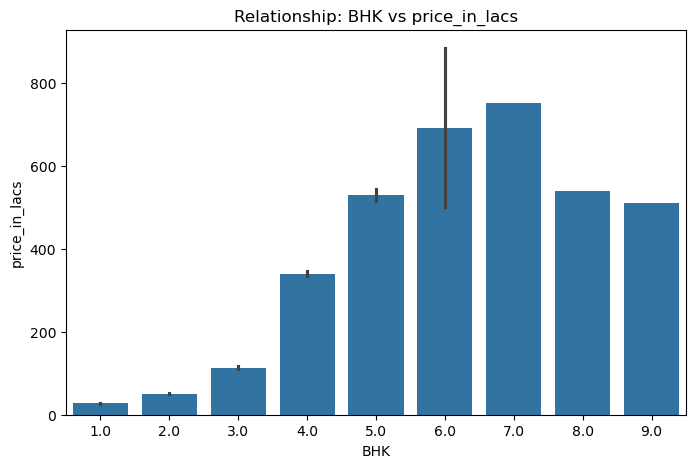

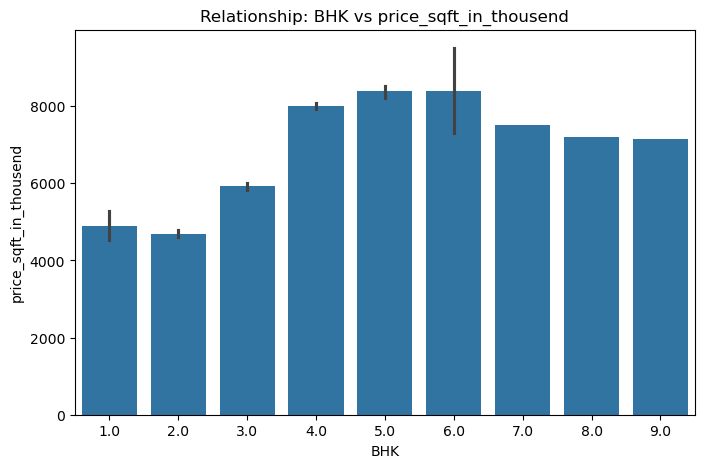

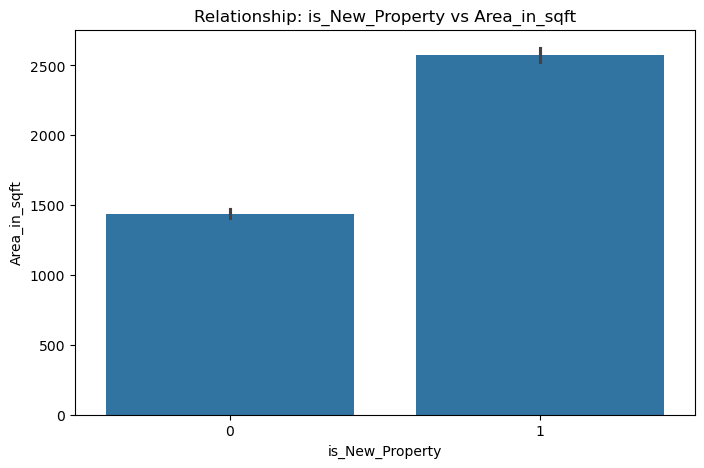

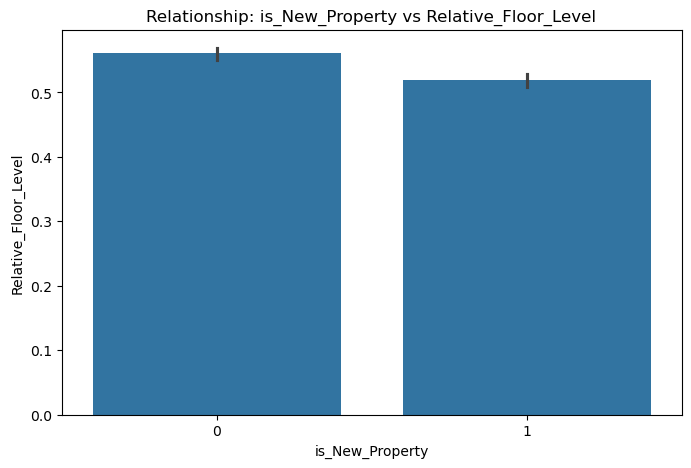

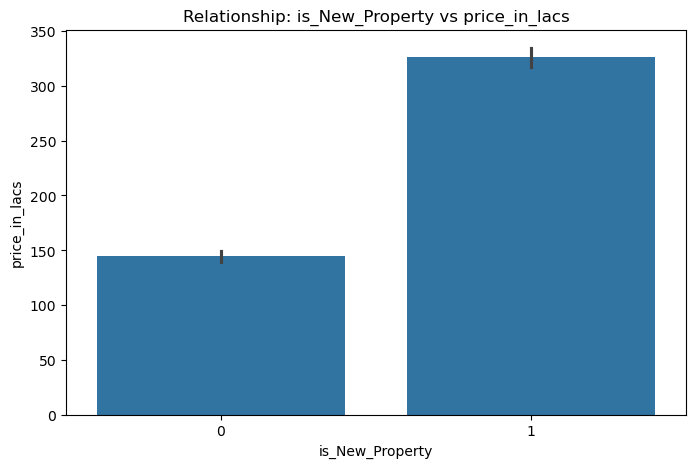

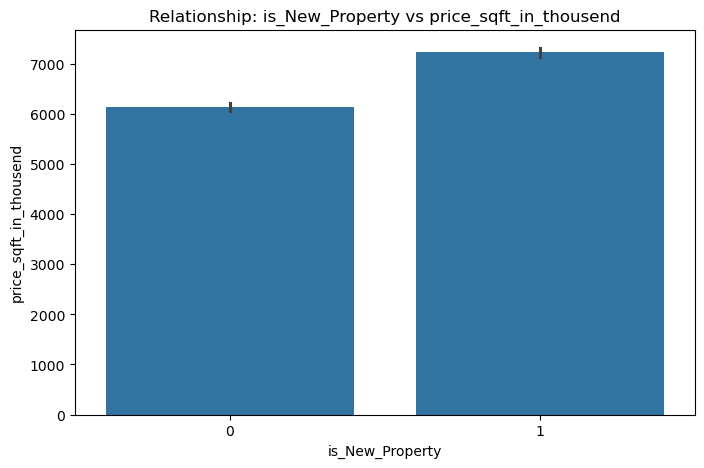

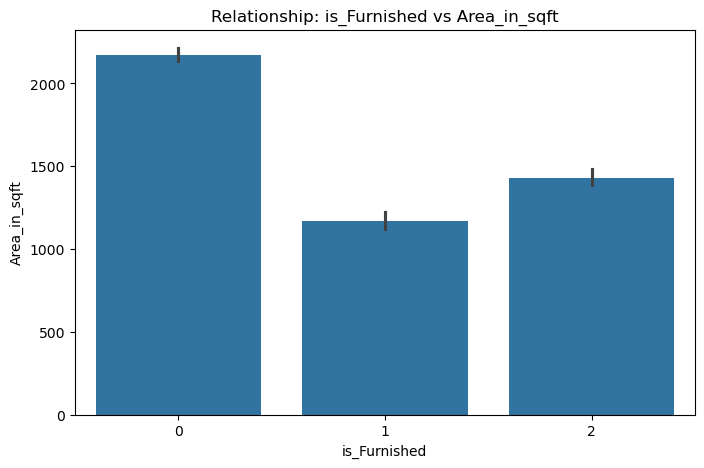

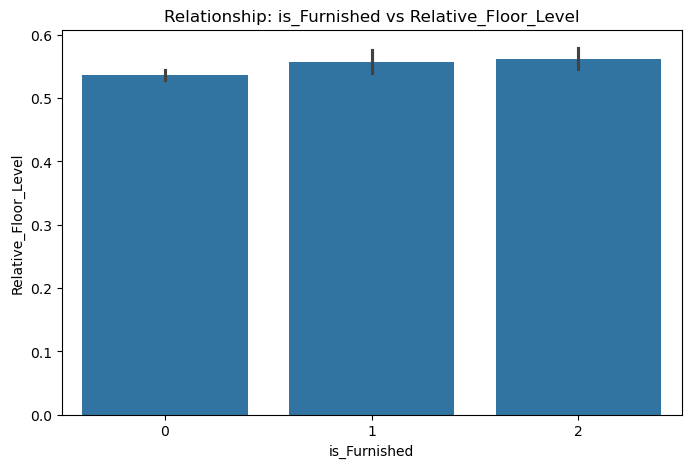

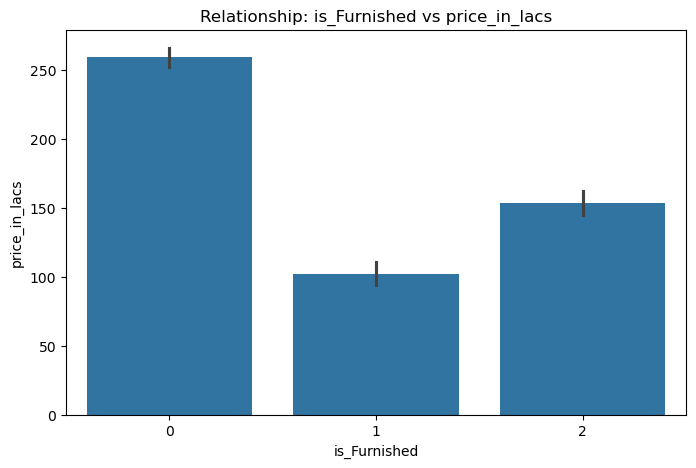

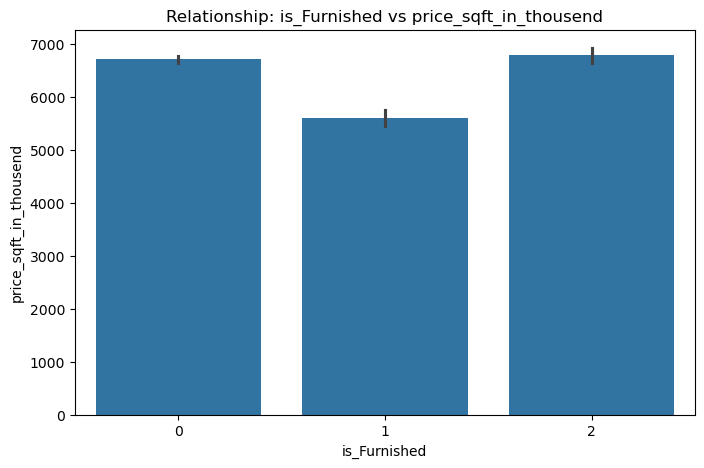

In [39]:
import seaborn as sns 
import matplotlib.pyplot as plt

for cat in cat_cols :
    for num_col in num_cols:
        plt.figure(figsize=(8,5))
        sns.barplot(data=df_ready,x=cat,y=num_col)
        plt.title(f"Relationship: {cat} vs {num_col}")
        plt.show()

        

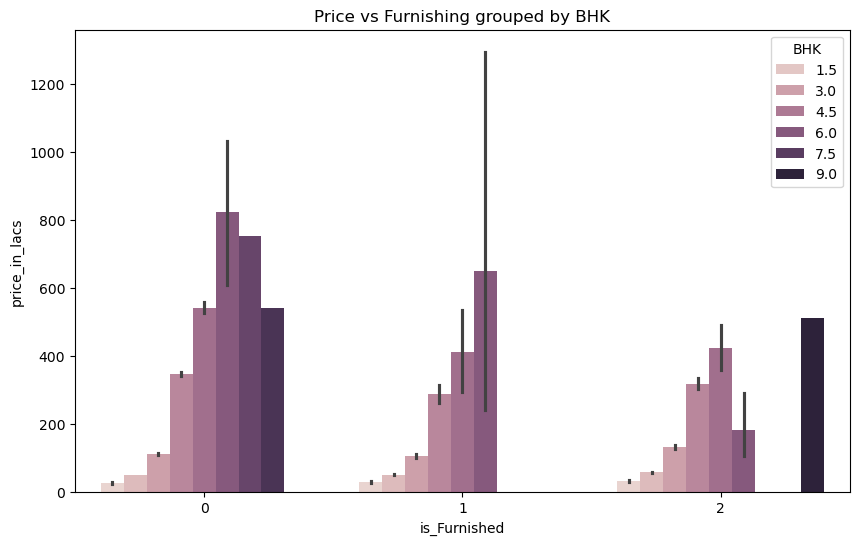

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_ready, x='is_Furnished', y='price_in_lacs', hue='BHK')
plt.title("Price vs Furnishing grouped by BHK")
plt.show()

In [41]:
pd.set_option('display.max_rows', 10)
df_ready.groupby(['is_Furnished',"BHK"]).size()

is_Furnished  BHK
0             1.0     123
              2.0     576
              3.0     910
              4.0    1641
              5.0     471
                     ... 
2             3.0     377
              4.0     246
              5.0      33
              6.0       4
              9.0       1
Length: 21, dtype: int64

In [42]:
df_ready=df_ready[df_ready["BHK"]<=6]

**Conclussion**
- Unfurnished flats avg price higher cause it mostly located in luxury area compare to furnished one

In [43]:
df_ready.groupby(['is_Furnished',"Area Name"]).size()

is_Furnished  Area Name
0             ambawadi      32
              ambli        485
              amraiwadi      5
              bapunagar      4
              bhadaj        14
                          ... 
2             vastral       29
              vastrapur     14
              vatva          6
              vinzol         1
              zundal         4
Length: 224, dtype: int64

### Category - Category

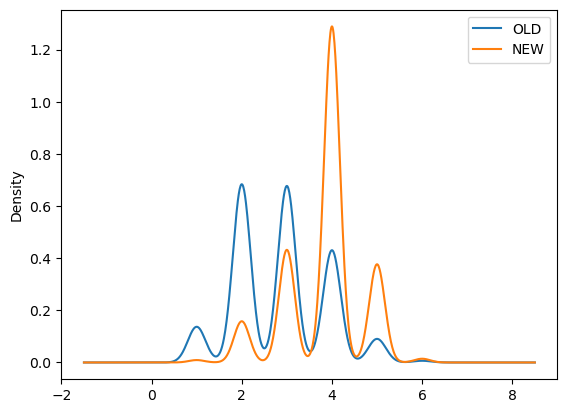

In [44]:
# is_New_property vs BHK
df_ready[df_ready['is_New_Property']==0]["BHK"].plot(kind="kde",label="OLD")
df_ready[df_ready['is_New_Property']==1]["BHK"].plot(kind="kde",label="NEW")
plt.legend()
plt.show()


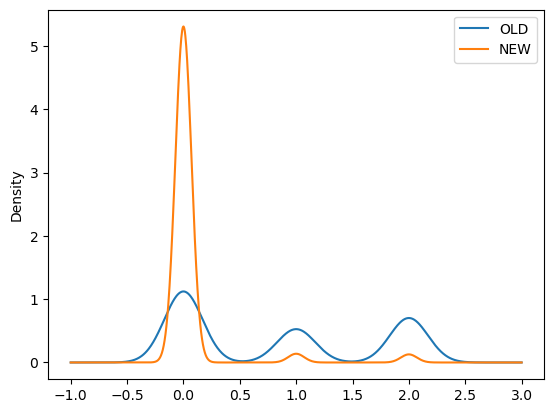

In [45]:
# is_New_property vs is_Furnished
df_ready[df_ready['is_New_Property']==0]["is_Furnished"].plot(kind="kde",label="OLD")
df_ready[df_ready['is_New_Property']==1]["is_Furnished"].plot(kind="kde",label="NEW")
plt.legend()
plt.show()


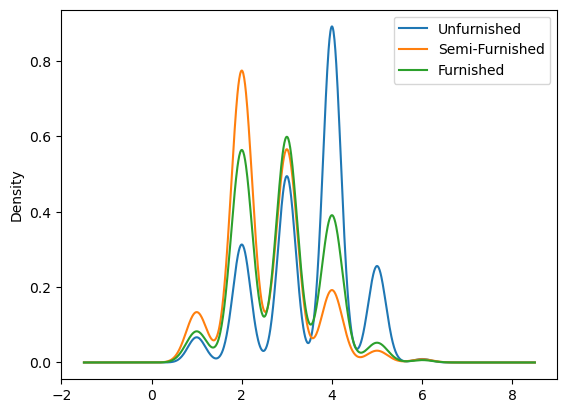

In [46]:
# is_Furnished vs BHK

df_ready[df_ready['is_Furnished']==0]["BHK"].plot(kind="kde",label="Unfurnished")
df_ready[df_ready['is_Furnished']==1]["BHK"].plot(kind="kde",label="Semi-Furnished")
df_ready[df_ready['is_Furnished']==2]["BHK"].plot(kind="kde",label="Furnished")

plt.legend()
plt.show()

In [47]:
df_ready

,Area_in_sqft,Relative_Floor_Level,BHK,price_in_lacs,price_sqft_in_thousend,is_New_Property,is_Furnished,Area Name,Area_Encoded
0,1033.0,0.571429,2.0,48.1,3444.0,1,0,zundal,4747.700812
1,710.0,0.571429,2.0,50.0,3876.0,1,0,shela,5641.517743
2,588.0,0.571429,2.0,40.0,3738.0,1,0,sanand,5988.045244
3,687.0,0.571429,2.0,48.8,3900.0,1,0,shela,5618.197769
4,621.0,0.571429,2.0,48.0,4248.0,1,0,gota,5468.142403
...,...,...,...,...,...,...,...,...,...
6847,3132.0,0.700000,4.0,486.0,9000.0,1,0,ambli,8810.142949
6848,3340.0,0.571429,4.0,650.0,11017.0,1,0,thaltej,8701.585141
6850,3132.0,0.800000,4.0,486.0,9000.0,1,0,ambli,8843.441955
6851,3900.0,0.727273,4.0,547.0,10393.0,1,0,sarkhej,6769.155734


# Splitting the Dataset 

In [62]:
from sklearn.model_selection import train_test_split 
y=df_ready['price_in_lacs']
X=df_ready.drop(columns=["price_in_lacs","price_sqft_in_thousend","Area Name"])

In [63]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Linear Regression

In [64]:
from sklearn import linear_model
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
Lin_model = linear_model.LinearRegression()
Lin_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
y_pred = Lin_model.predict(X_test)

r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print(f"R² : {r2:.4f}")
print(f"MAE : {mae:.2f} lacs")
print(f"RMSE : {rmse:.2f} lacs")

train_r2 = Lin_model.score(X_train,y_train)
test_r2 = Lin_model.score(X_test,y_test)

print(f"Train Score : {train_r2:.4f}")
print(f"Test Score : {test_r2:.4f}")
print(f"GAP : {train_r2 - test_r2 :.2f}")


R² : 0.8735
MAE : 47.33 lacs
RMSE : 69.09 lacs
Train Score : 0.8627
Test Score : 0.8735
GAP : -0.01


### **Conclusion**
- Our linear regression model perfomed well we got **R²=0.86** which is consider very good.
- But we also have **MAE** of around **50 lacs** which means our avrage estimation is 50 lacs far from original estinations. 
- Model's **RMSE** is **70 lacs** compare to our **MEA** the gap between two has very large, which is not good it happen   maybe because of the luxury flat that effect the model so it is not good for eatimating luxury flat but good for normal range flats.
- Both train and test sets **R² gap** is -0.01 which is very good cause it means our model is not over fitting.     

# Rnadom Forest

In [66]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()

In [67]:
rf_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
y_pred2 = rf_model.predict(X_test) 

r2 = r2_score(y_test,y_pred2)
mae = mean_absolute_error(y_test,y_pred2)
rmse = np.sqrt(mean_squared_error(y_test,y_pred2))

print(f"R² : {r2:.4f}")
print(f"MAE : {mae:.2f} lacs")
print(f"RMSE : {rmse:.2f} lacs")

train_r2 = rf_model.score(X_train,y_train)
test_r2 = rf_model.score(X_test,y_test)

print(f"Train Score : {train_r2:.4f}")
print(f"Test Score : {test_r2:.4f}")
print(f"GAP : {train_r2 - test_r2 :.2f}")

R² : 0.9134
MAE : 32.62 lacs
RMSE : 57.16 lacs
Train Score : 0.9878
Test Score : 0.9134
GAP : 0.07


## Hyper Tuning

In [69]:
from sklearn.model_selection import RandomizedSearchCV
param_grid ={
    'n_estimators':[100,200,300],
    'max_depth':[10,15,20],
    'min_samples_leaf':[2,4,6],
    'min_samples_split':[5,10,15]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions = param_grid,
    n_iter = 20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train,y_train)

print("Best Params : ",rf_random.best_params_)
print("Best CV R² :", rf_random.best_score_)

Best Params :  {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
Best CV R² : 0.9078088249218557


In [70]:
rf_model_hypr = RandomForestRegressor(n_estimators=300,min_samples_split=15,min_samples_leaf=6,max_depth=20)
rf_model_hypr.fit(X_train,y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,20
,min_samples_split,15
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
y_pred3 = rf_model_hypr.predict(X_test) 

r2 = r2_score(y_test,y_pred3)
mae = mean_absolute_error(y_test,y_pred3)
rmse = np.sqrt(mean_squared_error(y_test,y_pred3))

print(f"R² : {r2:.4f}")
print(f"MAE : {mae:.2f} lacs")
print(f"RMSE : {rmse:.2f} lacs")

train_r2 = rf_model_hypr.score(X_train,y_train)
test_r2 = rf_model_hypr.score(X_test,y_test)

print(f"Train Score : {train_r2:.4f}")
print(f"Test Score : {test_r2:.4f}")
print(f"GAP : {train_r2 - test_r2 :.2f}")

R² : 0.9111
MAE : 33.82 lacs
RMSE : 57.91 lacs
Train Score : 0.9392
Test Score : 0.9111
GAP : 0.03


### **Conclution**
- Here we have **R²** like **0.91** which is very good sligtly better than linear regression.
- We got **MAE** of like **34 lacs** which is far better than linear regrration.
- Still we got **RMSE** of like **58 lacs** which means our model still not consistence to pridict flats cause of gap of normal and luxury flats but better than linear regression.
- We gor GAP of **0.02** means our model overfitting which is common in random forest we drop gap by 0.07 to 0.02 which is great by hpertuning.

# XGBoosts

In [72]:
from xgboost import XGBRegressor

param_grid2 = {
    'n_estimators':[200,300,500],
    'learning_rate':[0.01,0.05,1],
    'max_depth':[4,6,8],
    'subsample':[0.7,0.8,0.9],
    'colsample_bytree':[0.7,0.8,0.9],
    'reg_alpha':[0,0.1,0.5],
    'reg_lambda':[1,1.5,2],
    'min_child_weight':[1,3,5],
}

xgb = XGBRegressor(random_state=42,n_jobs=-1)

xgb_random = RandomizedSearchCV(
    xgb,
    param_distributions = param_grid2,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_train,y_train)

print("Best params : ",xgb_random.best_params_)
print("Best CV R² : ",xgb_random.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params :  {'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV R² :  0.9134792233165167


In [83]:
xgb_best = XGBRegressor(
    subsample=0.8, 
    reg_lambda = 1.5,
    reg_alpha=0.1,
    n_estimators = 500,
    min_child_weight =5,
    max_depth =5,
    learning_rate =0.01,
    colsample_bytree = 0.8
)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

xgb_best.fit(X_train,y_train_log)

# xgb_best = xgb_random.best_estimator_
y_pred_log = xgb_best.predict(X_test)

y_pred4 = np.expm1(y_pred_log)

r2 = r2_score(y_test,y_pred4)
mae = mean_absolute_error(y_test,y_pred4)
rmse = np.sqrt(mean_squared_error(y_test,y_pred4))

print(f"R² : {r2:.4f}")
print(f"MAE : {mae:.2f} lacs")
print(f"RMSE : {rmse:.2f} lacs")

train3 = xgb_best.score(X_train,y_train_log)
test3 =  xgb_best.score(X_test,y_test_log)

print(f"Train Score : {train3:.4f}")
print(f"Test Score  : {test3:.4f}")
print(f"GAP         : {train3 - test3:.2f}")


R² : 0.9042
MAE : 35.00 lacs
RMSE : 60.12 lacs
Train Score : 0.9506
Test Score  : 0.9439
GAP         : 0.01


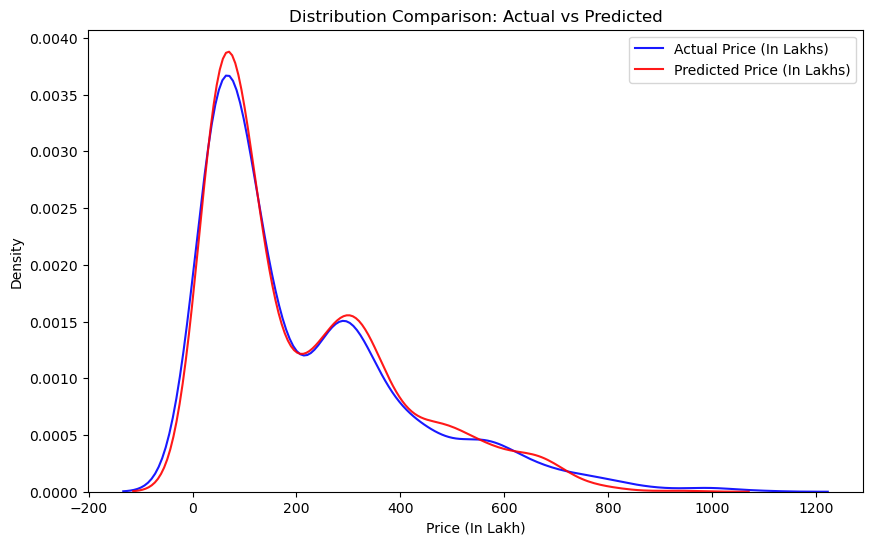

In [76]:
plt.figure(figsize=(10, 6))

# Plotting the Distribution of Actual Prices
sns.kdeplot(y_test, label="Actual Price (In Lakhs)", color="blue", alpha=0.9)

# Plotting the Distribution of Predicted Prices
sns.kdeplot(y_pred4, label="Predicted Price (In Lakhs)", color="red", alpha=0.9)

plt.title("Distribution Comparison: Actual vs Predicted")
plt.xlabel("Price (In Lakh)")
plt.ylabel("Density")
plt.legend()
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

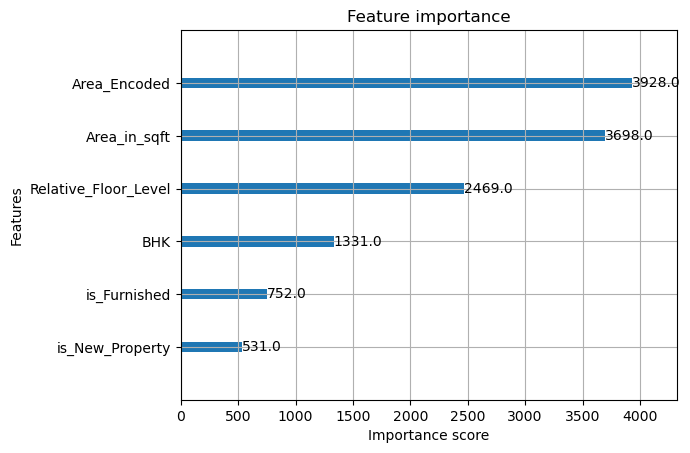

In [77]:
from xgboost import plot_importance
plot_importance(xgb_best)

In [89]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred2)

print(f"MAPE: {mape * 100:.2f}%")

MAPE: 18.09%


In [93]:
import pickle
with open("house_price_model.pkl","wb") as f:
    pickle.dump(xgb_best,f) 